In [ ]:
import tensorflow as tf
import json
import numpy as np
from matplotlib import pyplot as plt
import os
import albumentations as A
import cv2
import xml.etree.ElementTree as ET
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16

In [ ]:
# IMAGES_PATH = os.path.join('data','images')

# number_images = 30
# cap = cv2.VideoCapture(0)
# for imgnum in range(number_images):
#     print('Collecting image {}'.format(imgnum))
#     ret, frame = cap.read()
#     imgname = os.path.join(IMAGES_PATH, f'{str(uuid.uuid1())}.jpg')
#     cv2.imwrite(imgname, frame)
#     cv2.imshow('frame', frame)
#     time.sleep(0.5)

#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break
# cap.release()
# cv2.destroyAllWindows()

In [2]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg')
images.as_numpy_iterator().next()
def load_image(x): 
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img
images = images.map(load_image)
images.as_numpy_iterator().next()
type(images)

tensorflow.python.data.ops.map_op._MapDataset

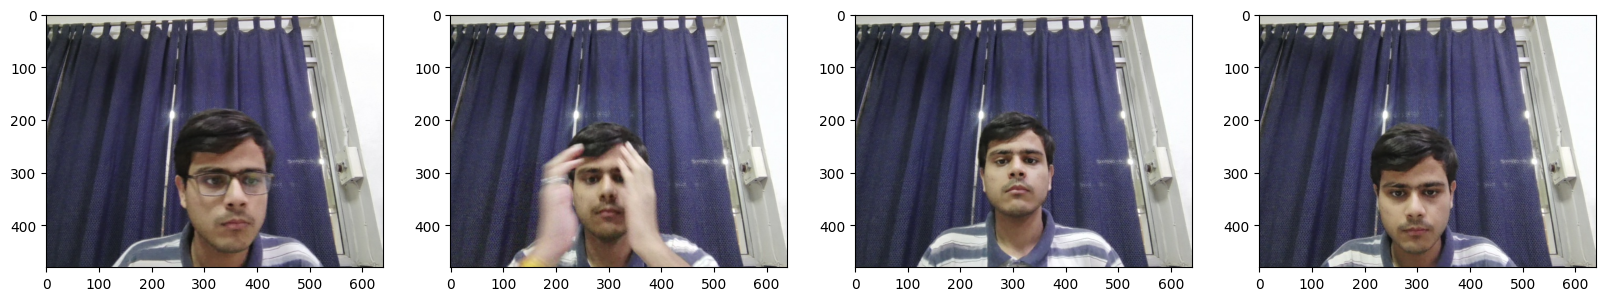

In [8]:
image_generator = images.batch(4).as_numpy_iterator()
plot_images = image_generator.next()
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image) 
plt.show()

In [10]:
for folder in ['train','test','val']:
    for file in os.listdir(os.path.join('data', folder, 'images')):
        filename = file.split('.')[0]+'.xml'
        existing_filepath = os.path.join('data','labels', filename)
        if os.path.exists(existing_filepath):
            new_filepath = os.path.join('data',folder,'labels',filename)
            os.replace(existing_filepath, new_filepath)

In [91]:
augmentor = A.Compose([
    A.RandomCrop(width=450, height=450, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),

    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.CLAHE(p=0.2),

    A.GaussianBlur(blur_limit=(3,5), p=0.3),
    A.MotionBlur(p=0.2),

    A.CoarseDropout(num_holes_range=(1, 2), hole_height_range=(0.05, 0.15), hole_width_range=(0.05, 0.15), p=0.3),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

In [92]:
image = cv2.imread("data/train/images/2f1ae20a-8a1e-11f0-89aa-a0b339cc0f14.jpg")
bboxes = [[239, 204, 427, 478]]
labels = ["face"]

augmented = augmentor(image=image, bboxes=bboxes, labels=labels)
aug_img = augmented['image']
aug_boxes = augmented['bboxes']

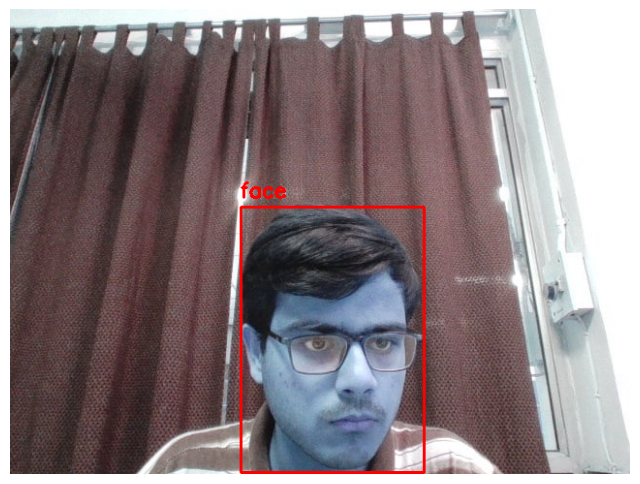

In [93]:
for box in aug_boxes:
    x_min, y_min, x_max, y_max = map(int, box)
    cv2.rectangle(aug_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
    cv2.putText(aug_img, "face", (x_min, y_min - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(aug_img)
plt.axis("off")
plt.show()

In [94]:
augmentor = A.Compose([
    A.RandomCrop(width=450, height=450, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),

    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.CLAHE(p=0.2),

    A.GaussianBlur(blur_limit=(3,5), p=0.3),
    A.MotionBlur(p=0.2),

    A.CoarseDropout(num_holes_range=(1, 2), hole_height_range=(0.05, 0.15), hole_width_range=(0.05, 0.15), p=0.3),
], bbox_params=A.BboxParams(format='albumentations', label_fields=['class_labels']))

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    obj = root.find("object")
    if obj is None:
        return None, None, w, h

    bbox = obj.find("bndbox")
    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    coords = [xmin, ymin, xmax, ymax]
    coords = list(np.divide(coords, [w, h, w, h]))
    return coords, "face", w, h

for partition in ['train','test','val']:
    os.makedirs(os.path.join('aug_data', partition, 'images'), exist_ok=True)
    os.makedirs(os.path.join('aug_data', partition, 'labels'), exist_ok=True)

for partition in ['train','test','val']:
    for image in os.listdir(os.path.join('data', partition, 'images')):
        img = cv2.imread(os.path.join('data', partition, 'images', image))

        coords = [0,0,0.00001,0.00001]
        xml_path = os.path.join('data', partition, 'labels', f'{image.split(".")[0]}.xml')

        if os.path.exists(xml_path):
            bbox, label, w, h = parse_xml(xml_path)
            if bbox:
                coords = bbox

        try:
            for x in range(60):
                augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                cv2.imwrite(os.path.join('aug_data', partition, 'images', f'{image.split(".")[0]}.{x}.jpg'), augmented['image'])

                annotation = {}
                annotation['image'] = image

                if os.path.exists(xml_path):
                    if len(augmented['bboxes']) == 0:
                        annotation['bbox'] = [0,0,0,0]
                        annotation['class'] = 0
                    else:
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = 1
                else:
                    annotation['bbox'] = [0,0,0,0]
                    annotation['class'] = 0

                with open(os.path.join('aug_data', partition, 'labels', f'{image.split(".")[0]}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)

        except Exception as e:
            print(e)


C:\Users\Akshat\AppData\Roaming\Python\Python313\site-packages\albumentations\augmentations\dropout\functional.py:559: RuntimeWarning: invalid value encountered in divide
  visibility_ratios = remaining_areas / box_areas


In [95]:
train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (120,120)))
train_images = train_images.map(lambda x: x/255)

test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (120,120)))
test_images = test_images.map(lambda x: x/255)

val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg', shuffle=False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (120,120)))
val_images = val_images.map(lambda x: x/255)

train_images.as_numpy_iterator().next()

array([[[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.92287576, 0.92679733, 0.86013067],
        [0.9137255 , 0.91764706, 0.8509804 ],
        [0.9137255 , 0.91764706, 0.8509804 ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.9232026 , 0.92712414, 0.8683006 ],
        [0.9166667 , 0.92058825, 0.8617647 ],
        [0.9196078 , 0.9235294 , 0.86470586]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.93333334, 0.9372549 , 0.88235295],
        [0.9254902 , 0.92941177, 0.8745098 ],
        [0.9258169 , 0.92973846, 0.8748365 ]],

       ...,

       [[0.8039216 , 0.8039216 , 0.77254903],
        [0.8029412 , 0.8068628 , 0.77254903],
        [0.79836607, 0

In [96]:
def load_labels(label_path):
    with open(label_path.numpy(), 'r', encoding = "utf-8") as f:
        label = json.load(f)
    return [label['class']], label['bbox']

def tf_load_labels(label_path):
    class_id, bbox = tf.py_function(load_labels, [label_path], [tf.uint8, tf.float32])
    class_id.set_shape([1])
    bbox.set_shape([4])
    return class_id, bbox

train_labels = tf.data.Dataset.list_files('aug_data/train/labels/*.json', shuffle=False)
train_labels = train_labels.map(tf_load_labels)

test_labels = tf.data.Dataset.list_files('aug_data/test/labels/*.json', shuffle=False)
test_labels = test_labels.map(tf_load_labels)

val_labels = tf.data.Dataset.list_files('aug_data/val/labels/*.json', shuffle=False)
val_labels = val_labels.map(tf_load_labels)

train_labels.as_numpy_iterator().next()

(array([1], dtype=uint8),
 array([0.33125   , 0.425     , 0.6265625 , 0.99583334], dtype=float32))

In [97]:
train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(8)
train = train.prefetch(4)

test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1300)
test = test.batch(8)
test = test.prefetch(4)

val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1000)
val = val.batch(8)
val = val.prefetch(4)

train.as_numpy_iterator().next()[1]

(array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]], dtype=uint8),
 array([[0.3397572 , 0.3472873 , 0.7161155 , 0.9632435 ],
        [0.15333334, 0.42444444, 0.5733333 , 1.        ],
        [0.4484375 , 0.55833334, 0.665625  , 0.9125    ],
        [0.3734375 , 0.5854167 , 0.6015625 , 0.98333335],
        [0.2822222 , 0.31777778, 0.75333333, 1.        ],
        [0.3390625 , 0.55833334, 0.55      , 0.9166667 ],
        [0.4140625 , 0.55833334, 0.61875   , 0.95208335],
        [0.378125  , 0.5854167 , 0.5703125 , 0.9479167 ]], dtype=float32))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


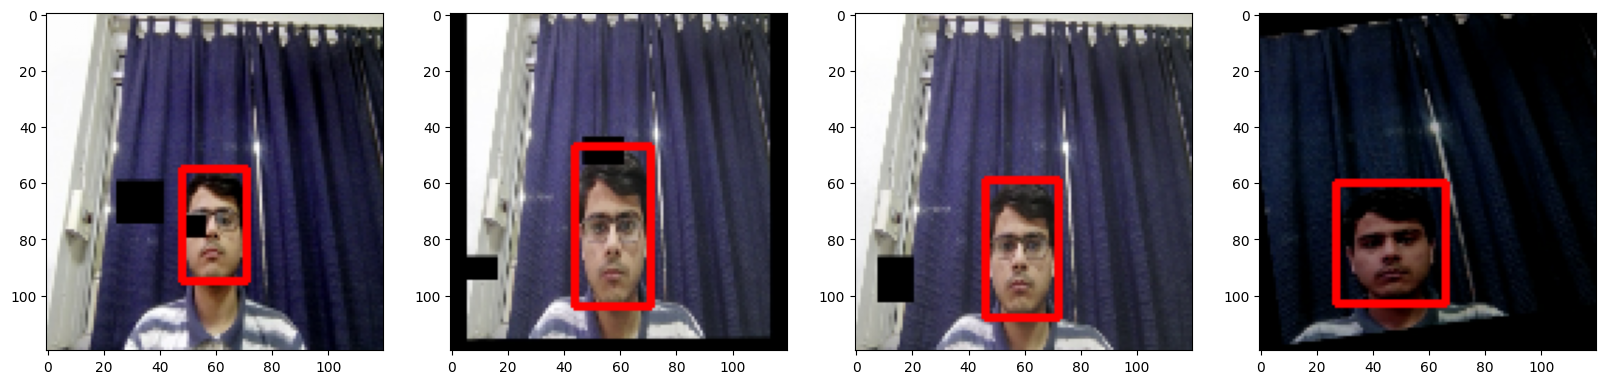

In [99]:
data_samples = train.as_numpy_iterator()
res = data_samples.next()
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    sample_image = res[0][idx].copy()
    sample_coords = res[1][1][idx]

    cv2.rectangle(sample_image, tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                    tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)), (255,0,0), 2)

    ax[idx].imshow(sample_image)

In [6]:
def build_model():
    input_layer = tf.keras.layers.Input(shape=(120,120,3))
    vgg = VGG16(include_top=False)(input_layer)

    f1 = tf.keras.layers.GlobalMaxPooling2D()(vgg)
    class1 = tf.keras.layers.Dense(2048, activation='relu')(f1)
    class2 = tf.keras.layers.Dense(1, activation='sigmoid', name="class_output")(class1)

    f2 = tf.keras.layers.GlobalMaxPooling2D()(vgg)
    regress1 = tf.keras.layers.Dense(2048, activation='relu')(f2)
    regress2 = tf.keras.layers.Dense(4, activation='sigmoid', name="bbox_output")(regress1)

    facetracker = Model(inputs=input_layer, outputs={"class_output": class2, "bbox_output": regress2})
    return facetracker


In [4]:
def localization_loss(y_true, yhat):
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - yhat[:,:2]))

    h_true = y_true[:,3] - y_true[:,1]
    w_true = y_true[:,2] - y_true[:,0]

    h_pred = yhat[:,3] - yhat[:,1]
    w_pred = yhat[:,2] - yhat[:,0]

    delta_size = tf.reduce_sum(tf.square(w_true - w_pred) + tf.square(h_true-h_pred))
    return delta_coord + delta_size

In [106]:
def format_labels(x, y):
    return x, {"class_output": y[0], "bbox_output": y[1]}

train = tf.data.Dataset.zip((train_images, train_labels))
train = train.map(format_labels)
train = train.shuffle(5000).batch(8).prefetch(4)

val = tf.data.Dataset.zip((val_images, val_labels))
val = val.map(format_labels)
val = val.shuffle(1000).batch(8).prefetch(4)

test = tf.data.Dataset.zip((test_images, test_labels))
test = test.map(format_labels)
test = test.shuffle(1300).batch(8).prefetch(4)

In [107]:
facetracker = build_model()

facetracker.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={
        "class_output": tf.keras.losses.BinaryCrossentropy(),
        "bbox_output": localization_loss
    },
    loss_weights={"class_output": 0.5, "bbox_output": 1.0},
    metrics={"class_output": "accuracy"}
)

history = facetracker.fit(train, validation_data=val, epochs=5, callbacks=[tf.keras.callbacks.TensorBoard(log_dir="logs")])

Epoch 1/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 934s 3s/step - bbox_output_loss: 0.3562 - class_output_accuracy: 0.9614 - class_output_loss: 0.1412 - loss: 0.4269 - val_bbox_output_loss: 0.0484 - val_class_output_accuracy: 1.0000 - val_class_output_loss: 0.0013 - val_loss: 0.0490
Epoch 2/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 784s 2s/step - bbox_output_loss: 0.0241 - class_output_accuracy: 1.0000 - class_output_loss: 3.8844e-04 - loss: 0.0243 - val_bbox_output_loss: 0.0093 - val_class_output_accuracy: 1.0000 - val_class_output_loss: 1.9885e-04 - val_loss: 0.0094
Epoch 3/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 1325s 4s/step - bbox_output_loss: 0.0091 - class_output_accuracy: 1.0000 - class_output_loss: 9.1729e-05 - loss: 0.0091 - val_bbox_output_loss: 0.0068 - val_class_output_accuracy: 1.0000 - val_class_output_loss: 4.8357e-05 - val_loss: 0.0069
Epoch 4/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 2038s 6s/step - bbox_output_loss: 0.0054 - class_output_accuracy: 1.0000 - class_output_loss: 4.0639e-05 - loss: 0.0054 - val_bb

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


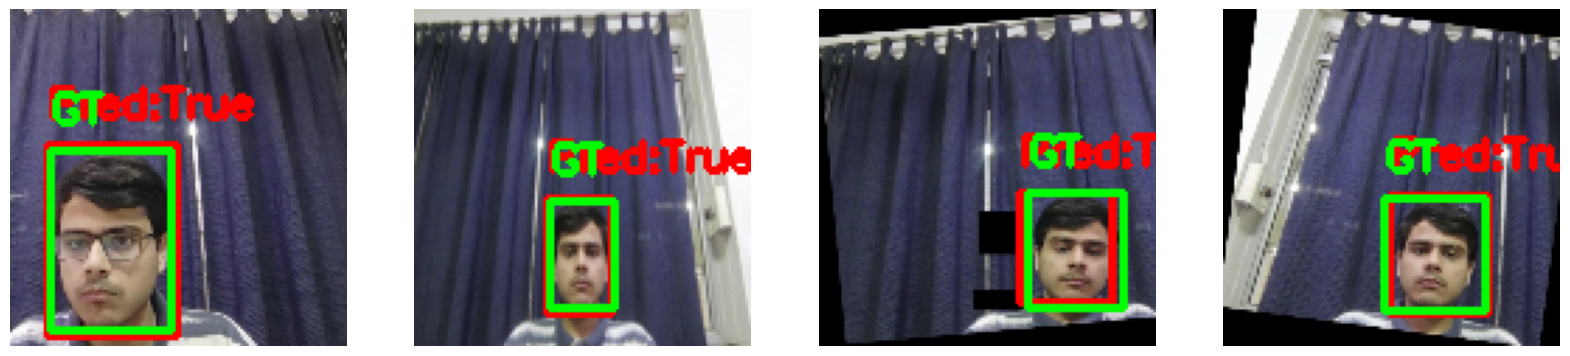

In [112]:
test_batch = test.take(1)
for images, labels in test_batch:
    preds = facetracker.predict(images)
    class_preds = preds["class_output"]
    bbox_preds = preds["bbox_output"]

    class_true = labels["class_output"]
    bbox_true = labels["bbox_output"]

fig, ax = plt.subplots(1, 4, figsize=(20, 20))
for i in range(4):
    img = images[i].numpy().copy()
    h, w, _ = img.shape

    pred_class = class_preds[i][0] > 0.5
    pred_box = bbox_preds[i]
    x_min, y_min, x_max, y_max = np.multiply(pred_box, [w, h, w, h]).astype(int)

    true_box = bbox_true[i].numpy()
    tx_min, ty_min, tx_max, ty_max = np.multiply(true_box, [w, h, w, h]).astype(int)

    img = (img * 255).astype(np.uint8)

    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
    cv2.putText(img, f"Pred:{pred_class}", (x_min, y_min - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    cv2.rectangle(img, (tx_min, ty_min), (tx_max, ty_max), (0, 255, 0), 2)
    cv2.putText(img, "GT", (tx_min, ty_min - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    ax[i].imshow(img)
    ax[i].axis("off")

In [116]:
facetracker.save('facetracker.keras')

In [5]:
from tensorflow.keras.models import load_model
facetracker = load_model('facetracker.keras', custom_objects={"localization_loss": localization_loss})

c:\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 36 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [22]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    _ , frame = cap.read()
    frame = frame[50:500, 50:500,:]

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = tf.image.resize(rgb, (120,120))

    yhat = facetracker.predict(np.expand_dims(resized/255,0), verbose=0)
    class_pred = yhat["class_output"][0][0]
    sample_coords = yhat["bbox_output"][0]

    if class_pred > 0.5:
        cv2.rectangle(frame, tuple(np.multiply(sample_coords[:2], [450,450]).astype(int)),
                    tuple(np.multiply(sample_coords[2:], [450,450]).astype(int)), (255,0,0), 2)
        cv2.rectangle(frame, tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int), [0,-30])),
                    tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),[80,0])), (255,0,0), -1)

        cv2.putText(frame, 'face', tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),[0,-5])),
        cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)

    cv2.imshow('EyeTrack', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()